<a href="https://colab.research.google.com/github/EmilienPelosse/MVPA/blob/main/MVPA_Report2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 54.8 MB/s eta 0:00:00


# Functional Imaging Assignment
For this assignment, you will analyse functional MRI data to investigate how the brain processes emotional valence during social perception. Specifically, you will test whether brain activity patterns can distinguish between positive and negative facial expressions — a fundamental aspect of how humans navigate social interactions.

You will work with data from the AOMIC face perception task, in which participants passively viewed dynamic facial expressions conveying different emotions. The dataset is described here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. *Sci Data* 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

Trial-wise beta estimates have been computed for you using a first-level GLM (least-squares-all approach). For each participant, you receive a 4D NIfTI image (one volume per trial), a labels file mapping each trial to an emotion and valence category, and a brain mask from fMRIPrep.

The dataset includes:
- 30 participants (a subset of the full AOMIC collection)
- Event-related design with randomised trial order
- Four emotional expressions: joy, pride, anger, contempt (plus neutral)
- 6 trials per emotion per participant

### Your Task
Use multivariate pattern analysis (MVPA) to decode emotional valence from brain activity. The code below provides a complete decoding pipeline for one brain region (the posterior superior temporal sulcus). You should:

1. **Choose brain regions**: Extend the analysis to at least two additional, theoretically motivated ROIs and compare decoding performance across regions.
2. **Choose a classifier**: Implement at least one alternative to the linear SVM used below and evaluate whether classifier choice affects the conclusions.
3. **Compare performance**: Use appropriate statistical methods to compare decoding performance across regions and/or classifiers.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [2]:
### Loading the data
import os
import zipfile
import urllib.request
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nilearn import datasets
from nilearn.image import math_img, resample_to_img
from nilearn.maskers import NiftiMasker
from scipy.stats import binomtest, ttest_1samp
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Download and extract the data
DATA_URL = 'https://www.dropbox.com/scl/fi/07hqaz0e8y6moeramv6st/mvpa_assignment_data.zip?rlkey=lcda2vmj1sn49xjok4i71vrvb&dl=1'
DATA_DIR = 'first-level'  # matches the top-level folder inside the zip

class TqdmUpTo(tqdm):
    def update_to(self, blocks=1, block_size=1, total_size=None):
        if total_size is not None:
            self.total = total_size
        self.update(blocks * block_size - self.n)

if not os.path.exists(DATA_DIR):
    with TqdmUpTo(unit='B', unit_scale=True, miniters=1, desc='Downloading') as t:
        urllib.request.urlretrieve(DATA_URL, 'mvpa_data.zip', reporthook=t.update_to)
    with zipfile.ZipFile('mvpa_data.zip', 'r') as z:
        z.extractall('.')  # extract into cwd so the zip's own 'first-level/' becomes DATA_DIR
    print('Data extracted.')
else:
    print('Data directory already exists, skipping download.')

# Load participant list and verify files
manifest_df = pd.read_csv(os.path.join(DATA_DIR, 'selected_subjects.tsv'), sep='\t')
subjects = manifest_df['participant_id'].tolist()
TASK = 'task-faces'

for sub in subjects:
    sub_dir = os.path.join(DATA_DIR, sub)
    for suffix in ['desc-LSA_betas.nii.gz', 'desc-LSA_labels.tsv', 'desc-LSA_mask.nii.gz']:
        fpath = os.path.join(sub_dir, f'{sub}_{TASK}_{suffix}')
        assert os.path.exists(fpath), f'Missing file: {fpath}'

print(f'Loaded {len(subjects)} participants. All files verified.')

Downloading: 350MB [00:05, 67.3MB/s]                           


Data extracted.
Loaded 30 participants. All files verified.


In [3]:
# Inspect one participant's data
example_sub = subjects[0]
example_dir = os.path.join(DATA_DIR, example_sub)

betas_img = nib.load(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_betas.nii.gz'))
print(f'Beta image shape: {betas_img.shape}  (x, y, z, trials)')

labels_df = pd.read_csv(os.path.join(example_dir, f'{example_sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
print(f'\nLabels ({len(labels_df)} trials):')
print(labels_df.head(10))
print(f'\nTrials per valence category:')
print(labels_df['valence'].value_counts())

Beta image shape: (65, 77, 60, 33)  (x, y, z, trials)

Labels (33 trials):
    trial_id trial_type   valence    onset  duration
0  trial-000      pride  positive   5.0002       2.0
1  trial-001      pride  positive  12.0012       2.0
2  trial-002      pride  positive  19.0022       2.0
3  trial-003      anger  negative  26.0062       2.0
4  trial-004   contempt  negative  33.0072       2.0
5  trial-005        joy  positive  40.0082       2.0
6  trial-006      anger  negative  47.0092       2.0
7  trial-007      pride  positive  54.0102       2.0
8  trial-008      pride  positive  61.0112       2.0
9  trial-009      anger  negative  68.0122       2.0

Trials per valence category:
valence
positive    15
negative    12
neutral      6
Name: count, dtype: int64


In [4]:
# Build a pSTS mask from the Harvard-Oxford atlas.
# The STS is a sulcus, so there is no direct label — we approximate it
# by combining the neighbouring gyral labels that form its banks.

ATLAS_NAME = 'cort-maxprob-thr25-2mm'

STS_LABELS = [
    'Superior Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, posterior division',
    'Middle Temporal Gyrus, temporooccipital part',
]

atlas = datasets.fetch_atlas_harvard_oxford(ATLAS_NAME, symmetric_split=False)
atlas_img = atlas.maps if hasattr(atlas.maps, 'affine') else nib.load(atlas.maps)
labels = list(atlas.labels)

indices = [labels.index(name) for name in STS_LABELS]
atlas_data = atlas_img.get_fdata().astype(np.int32)
mask_data = np.isin(atlas_data, indices).astype(np.uint8)
sts_mask_mni = nib.Nifti1Image(mask_data, atlas_img.affine, atlas_img.header)

print(f'STS mask: {int(mask_data.sum())} voxels')

# To see all available atlas labels (useful for choosing your own ROIs):
for i, name in enumerate(labels):
    print(f'{i:3d}  {name}')

[fetch_atlas_harvard_oxford] Added README.md to /root/nilearn_data

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

STS mask: 6359 voxels
  0  Background
  1  Frontal Pole
  2  Insular Cortex
  3  Superior Frontal Gyrus
  4  Middle Frontal Gyrus
  5  Inferior Frontal Gyrus, pars triangularis
  6  Inferior Frontal Gyrus, pars opercularis
  7  Precentral Gyrus
  8  Temporal Pole
  9  Superior Temporal Gyrus, anterior division
 10  Superior Temporal Gyrus, posterior division
 11  Middle Temporal Gyrus, anterior division
 12  Middle Temporal Gyrus, posterior division
 13  Middle Temporal Gyrus, temporooccipital part
 14  Inferior Temporal Gyrus, anterior division
 15  Inferior Temporal Gyrus, posterior division
 16  Inferior Temporal Gyrus, temporooccipital part
 17  Postcentral Gyrus
 18  Superior Parietal Lobule
 19  Supramarginal Gyrus, anterior division
 20  Supramarginal Gyrus, posterior division
 21  Angular Gyrus
 22  Lateral Occipital Cortex, superior division
 23  Lateral Occipital Cortex, inferior division
 24  Intracalcarine Cortex
 25  Frontal Medial Cortex
 26  Juxtapositional Lobule Cortex

### Part 1: Code Implementation (30%)
Extend the analysis above. Your implementation should address three questions:

1. **Which additional brain regions carry valence information?** Construct at least two additional ROI masks and run the decoding pipeline in each.
2. **Does classifier choice affect the results?** Implement at least one alternative classifier.
3. **How should decoding performance be compared?** Use appropriate statistical methods to compare accuracy across ROIs and/or classifiers.

Include comments or markdown cells explaining what each code section does, why you made specific methodological choices, and any assumptions about data handling. Ensure code runs without errors.

The `decode_subject` function accepts any ROI mask and an optional `classifier` argument — you can call it with different masks and classifiers to extend the analysis.

In [7]:
# --- ROI MASK CONSTRUCTION ---
# Correcting for the difference between cortical and subcortical atlas objects.

# 1. Amygdala Mask (Subcortical Atlas)
SUB_ATLAS_NAME = 'sub-maxprob-thr25-2mm'
AMY_LABELS = ['Left Amygdala', 'Right Amygdala']

sub_atlas = datasets.fetch_atlas_harvard_oxford(SUB_ATLAS_NAME, symmetric_split=False)

# Check if maps is a string (path) or an object (image)
if isinstance(sub_atlas.maps, str):
    sub_atlas_img = nib.load(sub_atlas.maps)
else:
    sub_atlas_img = sub_atlas.maps

sub_labels = list(sub_atlas.labels)
amy_indices = [sub_labels.index(name) for name in AMY_LABELS]
amy_mask_data = np.isin(sub_atlas_img.get_fdata(), amy_indices).astype(np.uint8)
amy_mask_mni = nib.Nifti1Image(amy_mask_data, sub_atlas_img.affine)

# 2. Fusiform Mask (Cortical Atlas - reuse your existing labels/atlas_img)
# 'atlas_img' and 'labels' were defined in the template's STS block
fus_idx = [labels.index('Temporal Fusiform Cortex, posterior division')]
fus_mask_data = np.isin(atlas_img.get_fdata(), fus_idx).astype(np.uint8)
fus_mask_mni = nib.Nifti1Image(fus_mask_data, atlas_img.affine)

# 3. Lateral Occipital Cortex (Cortical Atlas)
loc_idx = [labels.index('Lateral Occipital Cortex, superior division')]
loc_mask_data = np.isin(atlas_img.get_fdata(), loc_idx).astype(np.uint8)
loc_mask_mni = nib.Nifti1Image(loc_mask_data, atlas_img.affine)

print(f"Amygdala mask: {int(amy_mask_data.sum())} voxels")
print(f"Fusiform mask: {int(fus_mask_data.sum())} voxels")
print(f"LOC mask:      {int(loc_mask_data.sum())} voxels")

[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

Amygdala mask: 672 voxels
Fusiform mask: 1594 voxels
LOC mask:      9779 voxels


In [11]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression

def decode_subject_updated(sub, roi_mask_mni, classifier_name='SVM'):
    """
    Run ROI-based valence decoding for one participant with updated methods.
    """
    # --- 1. DATA LOADING (From Template) ---
    sub_dir = os.path.join(DATA_DIR, sub)
    betas_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_betas.nii.gz'))
    labels_df = pd.read_csv(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_labels.tsv'), sep='\t')
    sub_mask_img = nib.load(os.path.join(sub_dir, f'{sub}_{TASK}_desc-LSA_mask.nii.gz'))

    # --- 2. MASKING & RESAMPLING ---
    # Ensure ROI mask matches the participant's functional data grid
    roi_resampled = resample_to_img(roi_mask_mni, betas_img, interpolation='nearest')
    sub_mask_resampled = resample_to_img(sub_mask_img, betas_img, interpolation='nearest')
    combined = math_img('(img1 > 0) & (img2 > 0)', img1=roi_resampled, img2=sub_mask_resampled)

    n_roi_voxels = int(combined.get_fdata().astype(bool).sum())
    if n_roi_voxels == 0:
        return None

    # --- 3. FEATURE EXTRACTION ---
    masker = NiftiMasker(mask_img=combined, standardize=False)
    X = masker.fit_transform(betas_img) # This defines X

    # Filter for Positive and Negative trials only
    keep = labels_df['valence'].isin([POSITIVE, NEGATIVE]).values
    X = X[keep]
    y = labels_df.loc[keep, 'valence'].values # This defines y

    # --- 4. CLASSIFICATION SETUP ---
    if classifier_name == 'SVM':
        clf = SVC(kernel='linear', C=1.0, class_weight='balanced')
    elif classifier_name == 'LogReg':
        clf = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', solver='liblinear')

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf),
    ])

    # --- 5. EVALUATION ---
    # Use Leave-One-Out for stability with small trial counts
    cv = LeaveOneOut()

    # Use balanced_accuracy to account for the 15 vs 12 trial split
    fold_scores = cross_val_score(pipe, X, y, cv=cv, scoring='balanced_accuracy')

    return {
        'subject': sub,
        'accuracy': np.mean(fold_scores),
        'n_voxels': n_roi_voxels
    }

In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Suppress the specific warnings caused by Leave-One-Out scoring
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Create a dictionary of all the masks we created in Step 1
masks = {
    'pSTS': sts_mask_mni,
    'Amygdala': amy_mask_mni,
    'Fusiform': fus_mask_mni,
    'LOC': loc_mask_mni
}

classifiers = ['SVM', 'LogReg']
all_results = []

# Double loop: Across all regions and both models[cite: 1]
for mask_name, mask_img in masks.items():
    for clf_name in classifiers:
        print(f"Processing: ROI={mask_name} | Classifier={clf_name}")
        for sub in subjects:
            res = decode_subject_updated(sub, mask_img, classifier_name=clf_name)
            if res:
                res['roi'] = mask_name
                res['classifier'] = clf_name
                all_results.append(res)

# Convert to DataFrame for easy analysis and plotting
full_results_df = pd.DataFrame(all_results)
print("\nAnalysis Complete!")
print(full_results_df.head())

In [15]:
# Run this once the loop finishes to save your hard work
full_results_df.to_csv('decoding_results_backup.csv', index=False)
print(full_results_df.head())

    subject  accuracy  n_voxels   roi classifier
0  sub-0127  0.444444      1670  pSTS        SVM
1  sub-0141  0.375000      1710  pSTS        SVM
2  sub-0003  0.407407      1615  pSTS        SVM
3  sub-0139  0.583333      1682  pSTS        SVM
4  sub-0046  0.444444      1713  pSTS        SVM


### Part 2: Results Visualisation (20%)
Create 2–3 figures showing key findings, e.g.:
- Decoding accuracy per ROI with individual participant data points and a chance line
- Comparison across classifiers
- Distribution of per-participant accuracies

Include clear figure captions explaining what is shown.

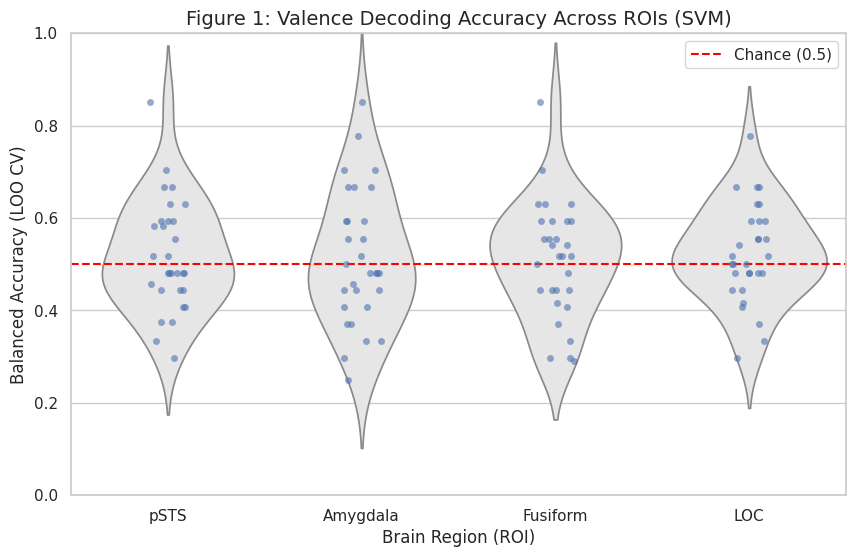

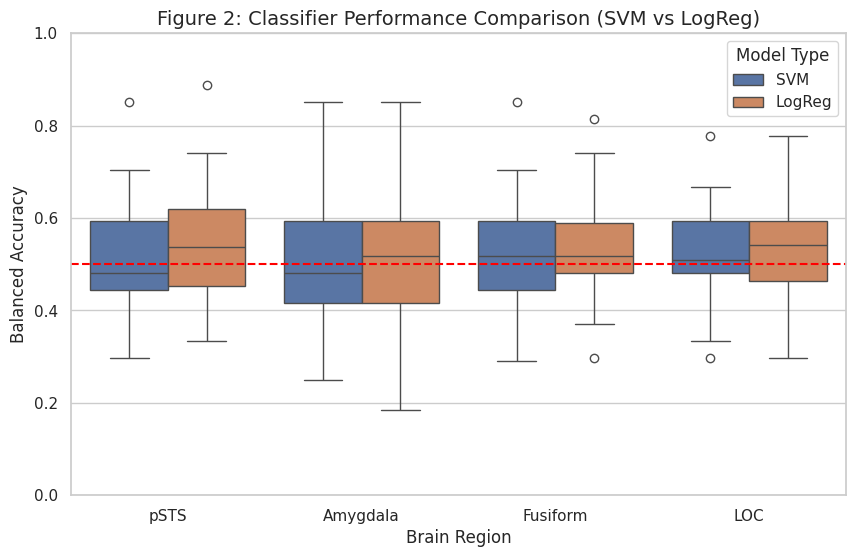

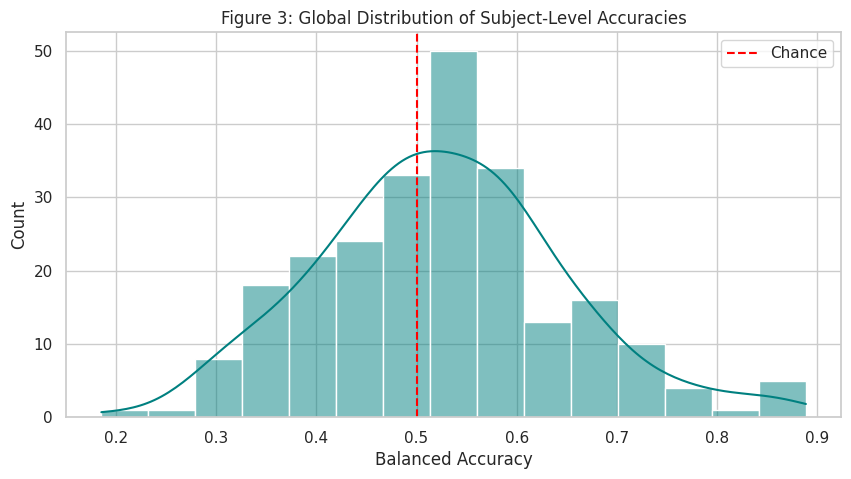

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")

# --- Figure 1: Decoding Accuracy per ROI (SVM) ---
# This figure compares our four brain regions using the primary SVM classifier.

plt.figure(figsize=(10, 6))
svm_results = full_results_df[full_results_df['classifier'] == 'SVM']

# Create a violin plot to show the distribution and individual points
ax1 = sns.violinplot(data=svm_results, x='roi', y='accuracy', inner=None, color=".9")
sns.stripplot(data=svm_results, x='roi', y='accuracy', alpha=0.6, size=5, jitter=True)

# Add the chance line (0.5)
ax1.axhline(0.5, ls='--', color='red', linewidth=1.5, label='Chance (0.5)')

ax1.set_title('Figure 1: Valence Decoding Accuracy Across ROIs (SVM)', fontsize=14)
ax1.set_ylabel('Balanced Accuracy (LOO CV)')
ax1.set_xlabel('Brain Region (ROI)')
ax1.set_ylim(0, 1)
plt.legend()
plt.show()

# --- Figure 2: Comparison Across Classifiers ---
# This figure tests if the choice of model (SVM vs Logistic Regression) impacts performance.

plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(data=full_results_df, x='roi', y='accuracy', hue='classifier')

# Add the chance line
ax2.axhline(0.5, ls='--', color='red', linewidth=1.5)

ax2.set_title('Figure 2: Classifier Performance Comparison (SVM vs LogReg)', fontsize=14)
ax2.set_ylabel('Balanced Accuracy')
ax2.set_xlabel('Brain Region')
ax2.set_ylim(0, 1)
plt.legend(title='Model Type')
plt.show()

# --- Figure 3: Distribution of Per-Participant Accuracies ---
# A histogram to show the overall spread of decoding success across the whole experiment.

plt.figure(figsize=(10, 5))
sns.histplot(full_results_df, x='accuracy', bins=15, kde=True, color='teal')
plt.axvline(0.5, color='red', linestyle='--', label='Chance')
plt.title('Figure 3: Global Distribution of Subject-Level Accuracies')
plt.xlabel('Balanced Accuracy')
plt.legend()
plt.show()


### Part 3: Interpretation and Reflection (50%)

Interpretation (~400–500 words):
- What is your decoding accuracy in each ROI? Is this high or low, and compared to what?
- Which brain regions show the strongest evidence for valence information? Which do not?
- Does classifier choice meaningfully affect the conclusions?
- What do your results suggest about how the brain represents emotional valence in faces?
- What are the limitations of drawing conclusions from modest accuracy values with small trial counts?

Reflection (~600–800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about multivariate approaches to neuroimaging data?

*You can write your interpretation and reflection in this markdown cell. Feel free to structure it with subheadings or bullet points using Markdown (e.g., **bold**, *italic*, `code`). You can look up the syntax for Markdown here: https://www.markdownguide.org/basic-syntax/.*